<a href="https://colab.research.google.com/github/Tedodor423/bms-collab-notebooks/blob/main/stats/3.4_Power/3.4.4_EffectSize.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Effect size (Cohen’s $d$)

The first ingredient in a power analysis is **effect size**.

A power analysis asks how large of a sample is needed to reliably detect an effect of a given size. To answer this, we need a way of quantifying how **large or small** an effect is.

**Effect size** measures how big the effect of interest is (for example, a difference in means or a correlation) *relative to the random variability or noise in the data*.

In this notebook we consider effect size for two common cases: **the $t$-test** and **Pearson's correlation**. We will see that:

* The effect size for the $t$-test is Cohen's $d$:

    * $ d = \frac{\bar{x_1}-\bar{x_2}}{s} $
    * *where $\bar{x}_1$ and $\bar{x}_2$ are the group means and $s$ is a measure of variability (typically the pooled standard deviation).*

* The effect size for a correlation is simply the correlation coefficient itself, $r$.

## Video

Here is a video explaining the idea of effect size for:
- differences of means (Cohen’s $d$)
- correlations (Pearson’s or Spearman’s $r$)


In [ ]:
%%HTML
<iframe width="560" height="315" src="https://www.youtube.com/embed/-KArntUcuys?si=cLeSnhcL7lycqtDj" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>

### Set up Python libraries

As usual, run the code cell below to import the relevant Python libraries

In [1]:
# Set-up Python libraries - you need to run this but you don't need to change it
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import seaborn as sns
sns.set_theme(style='white')
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.simplefilter('ignore', category=FutureWarning)

## Effect size for the $t$-test

**Example:**

A researcher hypothesises that geography students are taller than psychology students.

$\mathcal{H_o}:$ The mean heights of psychology ($\mu_p$) and geography ($\mu_g$) students are the same; $\mu_p = \mu_g$

$\mathcal{H_a}:$ The mean heights of geography students is greater than the mean height of psychology students; $\mu_g > \mu_p$


The researcher measures measures the heights of 12 geography students an 10 psychology students, which are given in the dataframe below:

In [ ]:
heights=pd.read_csv('https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook_2025/main/data/PsyGeogHeights.csv')
heights

,studentID,subject,height
0,186640,psychology,154.0
1,588140,psychology,156.3
2,977390,psychology,165.6
3,948470,psychology,162.0
4,564360,psychology,162.0
5,604180,psychology,159.0
6,770760,psychology,166.1
7,559170,psychology,165.9
8,213240,psychology,163.7
9,660220,psychology,165.6


Let's calculate the sample mean for each subject group:

In [ ]:
heights.groupby('subject').height.mean()

subject
geography     168.460
psychology    163.325
Name: height, dtype: float64

The geography students are, on average, about 5 cm taller than the psychology students.

Is this a large difference? Would it be obvious at a psychology–geography student party who was studying which subject, based on height alone?

To build some intuition, it is helpful to visualise how much the two populations overlap by plotting their height distributions (KDE + Rug is a good choice):

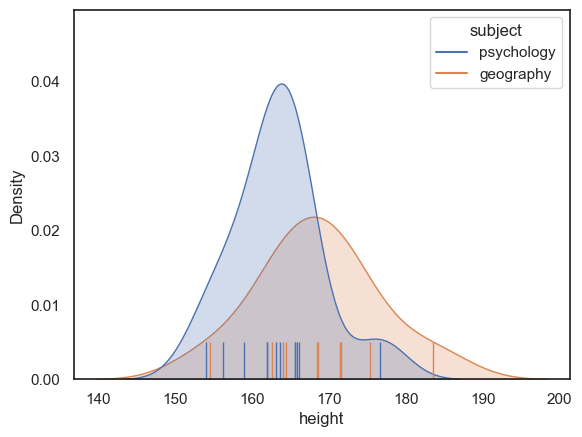

In [ ]:
# plot KDEs
sns.kdeplot(data=heights, x='height', hue='subject', fill=True)
sns.rugplot(data=heights, x='height', hue='subject', height=0.1)

plt.show()

Hm, no, we probably could not tell who is a psychology student and who is a geography student, just from their heights. However the plot does suggest that there is a difference between the groups overall, despite the overlap.

### Effect size $\neq$ statistical significance

We could ask if there is a statistically signifiant difference between the groups by running a $t$-test. Because we are looking at height, it is safe to assume the populations are normally distributed:

In [ ]:
stats.ttest_ind(heights.query('subject=="geography"').height,
                heights.query('subject=="psychology"').height,
                alternative='greater')

TtestResult(statistic=np.float64(1.7743564827449236), pvalue=np.float64(0.04561467878556142), df=np.float64(20.0))

The difference is *just* significant at $\alpha$=0.05 - our $p$-value is 0.0456

However, this doesn't really tell us whether the effect itself is big (i.e., the magnitude of the difference, which would allow us to identify a student's subject based on height). That's because the value of $t$ and therefore $p$ also depends on the sample size, $n$. Holding the group means and SDs fixed, the two-sample $t$ statistic grows as the sample sizes increase (roughly like $\sqrt{n}$), so the same effect can be non-significant in a small sample but highly significant in a large one.

To illustrate this, consider the second sample `heights2`, which is ten times larger (120 psychology students and 100 geography students), but with the same mean and sd in each group as the small ($n$ = 12,10) sample:

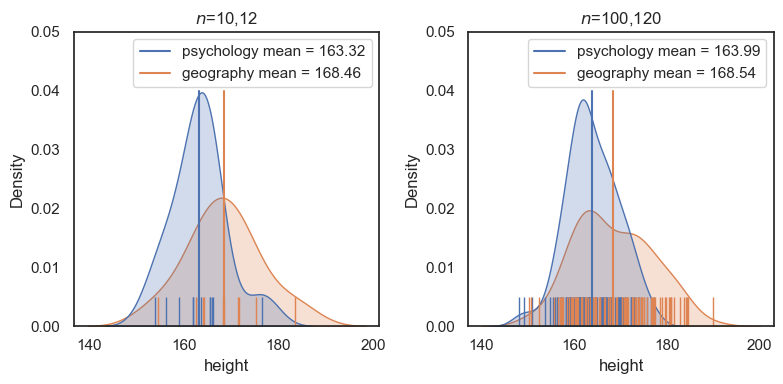

In [ ]:
heights2 = pd.read_csv('https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook_2025/main/data/heightsLargerSample.csv')

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title('$n$=10,12')
sns.kdeplot(data=heights, x='height', hue='subject', fill=True)
sns.rugplot(data=heights, x='height', hue='subject', height=0.1)
plt.plot([heights.query('subject == "psychology"').height.mean(),heights.query('subject == "psychology"').height.mean()], [0,.04], label = 'psychology mean = {:.2f}'.format(heights.query('subject == "psychology"').height.mean()))
plt.plot([heights.query('subject == "geography"').height.mean(),heights.query('subject == "geography"').height.mean()], [0,.04], label = 'geography mean = {:.2f}'.format(heights.query('subject == "geography"').height.mean()))

plt.legend(loc='best')


plt.subplot(1,2,2)
plt.title('$n$=100,120')
sns.kdeplot(data=heights2, x='height', hue='subject', fill=True)
sns.rugplot(data=heights2, x='height', hue='subject', height=0.1)
plt.plot([heights2.query('subject == "psychology"').height.mean(),heights2.query('subject == "psychology"').height.mean()], [0,.04], label = 'psychology mean = {:.2f}'.format(heights2.query('subject == "psychology"').height.mean()))
plt.plot([heights2.query('subject == "geography"').height.mean(),heights2.query('subject == "geography"').height.mean()], [0,.04], label = 'geography mean = {:.2f}'.format(heights2.query('subject == "geography"').height.mean()))

plt.legend(loc='best')
plt.tight_layout()
plt.show()

Although the means and standard deviations for each group are about the same, conducting a $t$-test on the larger dataset shows that the difference is *much* more statistically significant.

*Note:* it is technically problematic to describe a result as “more” or “less” significant, since statistical significance is formally a binary concept (significant or not significant). However, the underlying point still holds: with a larger sample size, the same effect leads to a much smaller $p$-value.


In [ ]:
# small sample size
stats.ttest_ind(heights.query('subject=="geography"').height,
                heights.query('subject=="psychology"').height,
                alternative='greater')

TtestResult(statistic=np.float64(1.7743564827449236), pvalue=np.float64(0.04561467878556142), df=np.float64(20.0))

In [ ]:
# large sample size
stats.ttest_ind(heights2.query('subject=="geography"').height,
                heights2.query('subject=="psychology"').height,
                alternative='greater')

TtestResult(statistic=np.float64(4.770032273659233), pvalue=np.float64(1.6851503676180662e-06), df=np.float64(218.0))

**Conclusion:**  The $t$-test cannot tell us whether the effect of subject studied on height is large or small. For that, we need a *pure* measure of effect size which quantifies the size of the difference relative to variability and independently of the sample size $n$.



## Variance matters for effect size

Is a 5 cm difference in height between psychology and geography students a large effect? How easily could we spot a tall geographer gatecrashing a PsychSoc party?

The answer depends not only on the **difference in mean heights**, but also on the **variability** (standard deviation) within each group.

To see this, consider the following dataset, which has the same difference in group means as before, but much **less variability** within each group:


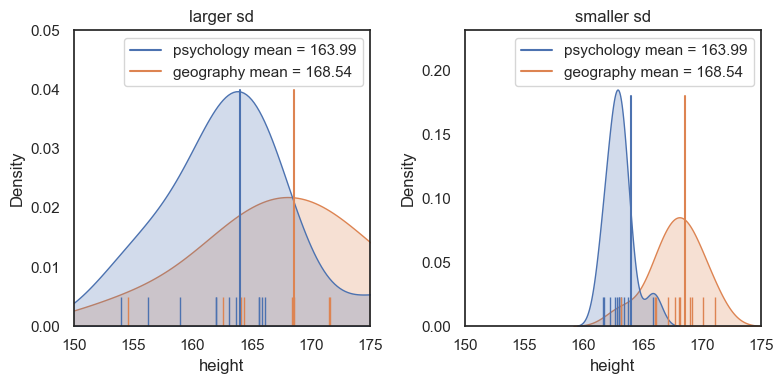

In [ ]:
heights3 = pd.read_csv('https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook_2025/main/data/heightsSmallerSD.csv')

plt.figure(figsize=(8,4))
# plot KDEs
plt.subplot(1,2,1)
plt.title('larger sd')
sns.kdeplot(data=heights, x='height', hue='subject', fill=True)
sns.rugplot(data=heights, x='height', hue='subject', height=0.1)
plt.xlim([150,175])
plt.plot([heights2.query('subject == "psychology"').height.mean(),heights2.query('subject == "psychology"').height.mean()], [0,.04], label = 'psychology mean = {:.2f}'.format(heights2.query('subject == "psychology"').height.mean()))
plt.plot([heights2.query('subject == "geography"').height.mean(),heights2.query('subject == "geography"').height.mean()], [0,.04], label = 'geography mean = {:.2f}'.format(heights2.query('subject == "geography"').height.mean()))
plt.legend(loc='best')

plt.subplot(1,2,2)
plt.title('smaller sd')
sns.kdeplot(data=heights3, x='height', hue='subject', fill=True)
sns.rugplot(data=heights3, x='height', hue='subject', height=0.1)
plt.xlim([150,175])
plt.plot([heights2.query('subject == "psychology"').height.mean(),heights2.query('subject == "psychology"').height.mean()], [0,.18], label = 'psychology mean = {:.2f}'.format(heights2.query('subject == "psychology"').height.mean()))
plt.plot([heights2.query('subject == "geography"').height.mean(),heights2.query('subject == "geography"').height.mean()], [0,.18], label = 'geography mean = {:.2f}'.format(heights2.query('subject == "geography"').height.mean()))
plt.legend(loc='best')

plt.tight_layout()
plt.show()

For the dataset on the right (with lower standard deviation within each group), we see a much clearer separation between psychology and geography students. In practical terms, it would be easier to guess a person’s subject based on their height.

The plot on the right therefore shows a **larger effect size**, as we will see in the next section.

## Cohen’s $d$

We quantify the effect size for a difference in means using **Cohen’s $d$**:

$$
d = \frac{\bar{x}_g - \bar{x}_p}{s}
$$

where:
- $\bar{x}_g$ is the mean height of the geography students,
- $\bar{x}_p$ is the mean height of the psychology students,
- $s$ is the **shared (pooled) standard deviation**, based on the sample standard deviations of the two groups, $s_p$ and $s_g$.

The pooled standard deviation is given by:

$$
s = \sqrt{\frac{(n_p - 1)s_p^2 + (n_g - 1)s_g^2}{n_p + n_g - 2}}
$$


Oof! that looks gross.

The *shared variance (or standard deviation) estimate*, $s$, is simply a way of obtaining a single “typical” standard deviation when we have two groups, each with their own sample standard deviation. It combines the information from both groups into one pooled estimate of variability.

Importantly, this pooled standard deviation is not something new or exotic — it already appears in the formula for the independent-samples $t$-test:

$$
t = \frac{\bar{x}_1 - \bar{x}_2}{s \sqrt{\frac{1}{n_1} + \frac{1}{n_2}}}
$$

Cohen’s $d$ is therefore closely related to the $t$ statistic. The key difference is that Cohen’s $d$ isolates the **size of the mean difference relative to variability**, whereas the $t$ statistic additionally scales this difference by sample size.


In [ ]:
# calculate shared standard deviation s

xP = heights.query('subject=="psychology"').height.mean()
xG = heights.query('subject=="geography"').height.mean()

sP = heights.query('subject=="psychology"').height.std()
sG = heights.query('subject=="geography"').height.std()

nP = heights.query('subject=="psychology"').height.count()
nG = heights.query('subject=="geography"').height.count()

s=(((nP-1)*(sP**2) + (nG-1)*(sG**2))/(nP+nG-2))**0.5 # **0.5 means 'to the power of a half' ie square root
s

np.float64(6.758944074335872)

$s$ is an estimate of the standard deviation of heights, based on both groups, so it should be similar to the standard deviation of each of the individual groups.

Now we can calculate our effect size:

In [ ]:
# Cohen's d
d=(xG-xP)/s

print(d)

0.759734056610692


So **$d = 0.76$** — that is, the difference in mean heights between psychology and geography students is 0.76 standard deviations.

### Effect size is a *standardised* measure

By dividing the difference in means by the standard deviation, we are expressing the separation between the two groups *relative to their variability*, rather than in the original measurement units.

This means that effect size quantifies the degree of overlap between the two distributions, independently of the absolute scale of the data.

As a result, quite different datasets can have the same effect size. For example, if both the difference in means *and* the standard deviations increase proportionally, the effect size can remain unchanged.

To illustrate this, consider the following dataset, which has the same effect size ($d = 0.76$) but now compares the weights of two groups of (fictional) black and grey sheep

Here we'll read in the sheep data, and calculate d as before:

In [ ]:
sheep=pd.read_csv('https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook_2025/main/data/SheepWeights.csv')

# calculate shared standard deviation s

xB = sheep.query('woolColor=="black"').weight.mean()
xG = sheep.query('woolColor=="grey"').weight.mean()

sB = sheep.query('woolColor=="black"').weight.std()
sG = sheep.query('woolColor=="grey"').weight.std()

nB = sheep.query('woolColor=="black"').weight.count()
nG = sheep.query('woolColor=="grey"').weight.count()

s_sheep=(((nB-1)*(sB**2) + (nG-1)*(sG**2))/(nB+nG-2))**0.5 # **0.5 means 'to the power of a half' ie square root
d_sheep=(xB-xG)/s_sheep

print(d_sheep)

0.7603268858269596


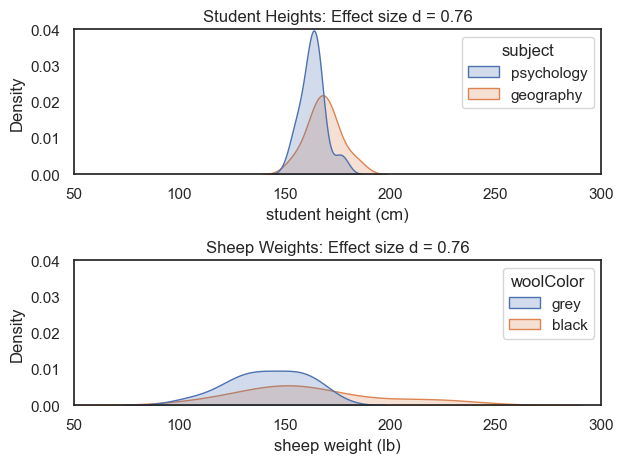

In [ ]:

# plot KDEs for psy/geog heights
plt.subplot(2,1,1)
sns.kdeplot(data=heights, x='height', hue='subject', fill=True)
plt.xlabel('student height (cm)')
plt.xlim([50,300])
plt.ylim([0,0.04])
plt.title('Student Heights: Effect size d = {:.2f}'.format(d))

# plot KDEs for black/grey sheep weights
plt.subplot(2,1,2)
sns.kdeplot(data=sheep, x='weight', hue='woolColor', fill=True)
plt.xlabel('sheep weight (lb)')
plt.xlim([50,300])
plt.ylim([0,0.04])
plt.title('Sheep Weights: Effect size d = {:.2f}'.format(d_sheep))

plt.tight_layout()
plt.show()

Although the sheep data are much more spread out, the difference in means between the groups is also larger.

As a result, these two very different datasets have the same effect size. Cohen’s $d$ therefore captures the *overlap between groups*, and it doesn't matter whether those groups are psychology and geography students, or black and grey sheep—independently of the units or overall spread of the data.


### Small, medium, and large effects

Cohen proposed the following rough benchmarks for interpreting the size of an effect:

- $d = 0.2$: small effect  
- $d = 0.5$: medium effect  
- $d = 0.8$: large effect  

He described a medium effect ($d = 0.5$) as one that is *“visible to the naked eye of a careful observer.”*

The plots below illustrate what these effect sizes look like when the data in each group are Normally distributed:
    
<img src="https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook_2024/main/images/Chp8_EffectSize
.png" width=95% >


Of course, even very small differences are “visible to the naked eye” when we look at smooth, idealised curves. In real data, however, there is uncertainty about how well a fitted curve (such as a KDE) represents the underlying population, and our confidence in the fit will depend on the sample size.

For this reason, to assess our confidence in an observed difference, that is, its **statistical significance**, we need to consider the sample size ($n$) as well as the effect size.


## Recovering $d$ from $t$

Many published papers do not report effect sizes or Cohen’s $d$ for $t$-tests. However, they typically do report the $t$ statistic and the sample size.

Fortunately, Cohen’s $d$ can be recovered relatively easily from the reported $t$ value and sample size. The relevant formulae (for both paired and independent-samples $t$-tests) are given on the page **4.9 Knowing the effect size**.

This is important because we often need to use the effect size from a published study to *estimate* the expected effect size in a study we are planning, and then choose an appropriate sample size using a power analysis. We will explore this process later in this chapter.